$\textbf{Problem}$: Write functions that take an arbitrary grayscale image and convolve them with a Sobel edge detection kernel. Apply both functions to a grayscale image of your choice.

$\textbf{Solution}$:

Original Image


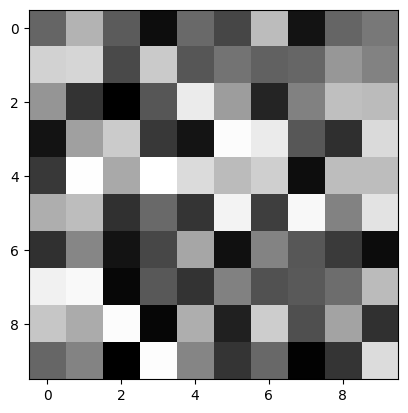

Horizontal Sobel


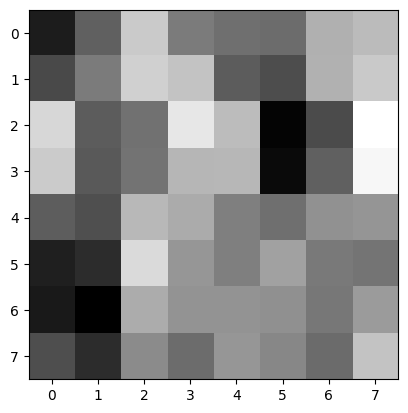

Vertical Sobel


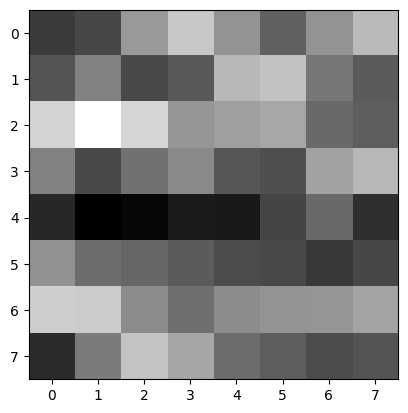

In [2]:
import numpy as np
import matplotlib.pyplot as plt

sobel_horizontal_kernel = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])
sobel_vertical_kernel = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]])

def sobel_horizontal(img):
    convolved_image = np.zeros(shape=(img.shape[0]-2,img.shape[1]-2))
    for i in range(1,img.shape[0] - 1):
        for j in range(1,img.shape[1] - 1):
            convolved_image[i-1, j-1] = np.sum(img[i-1:i+2, j-1:j+2] * sobel_horizontal_kernel)
    return convolved_image

def sobel_vertical(img):
    convolved_image = np.zeros(shape=(img.shape[0]-2,img.shape[1]-2))
    for i in range(1,img.shape[0] - 1):
        for j in range(1,img.shape[1] - 1):
            convolved_image[i-1, j-1] = np.sum(img[i-1:i+2, j-1:j+2] * sobel_vertical_kernel)
    return convolved_image

np.random.seed(42)
random_grayscale_img = np.random.randint(0, 256, size=(10, 10))

print("Original Image")
plt.imshow(random_grayscale_img, cmap="gray")
plt.show()

print("Horizontal Sobel")
plt.imshow(sobel_horizontal(random_grayscale_img), cmap="gray")
plt.show()

print("Vertical Sobel")
plt.imshow(sobel_vertical(random_grayscale_img), cmap="gray")
plt.show()

$\textbf{Problem}$: Above, the $3\times 3$ Sobel edge detection kernels were convolved with an $n\times m$ 
grayscale image, leading to an $(n-2)\times (m-2)$ edge map. However, although for $n, m \gg 1$ this $-2$ shrinking effect 
is not particularly noticeable, over many layers of convolutions it can compound undesirably. Thus, one solution is to use $\textit{padding}$ to prevent this shrinking effect. Show how this works.

$\textbf{Solution}$: (by the way, the above unpadded version is sometimes called a $\textit{valid}$ convolution, 
whereas the padded version is sometimes called a $\textit{same}$ convolution).

Padded random grayscale image shape:  (12, 12)


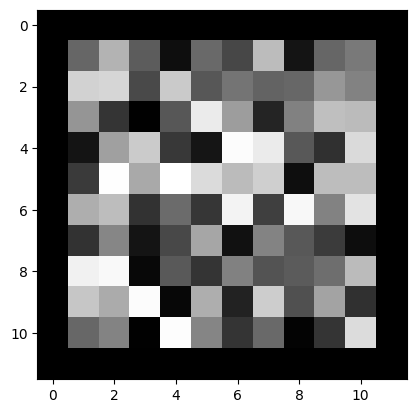

Horizontal Sobel


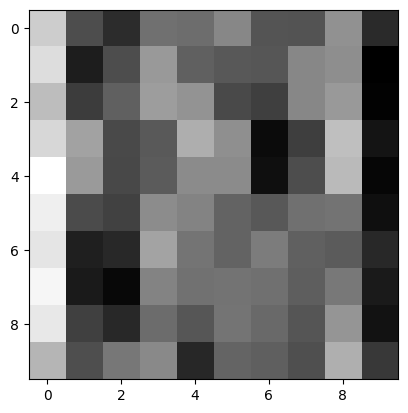

Vertical Sobel


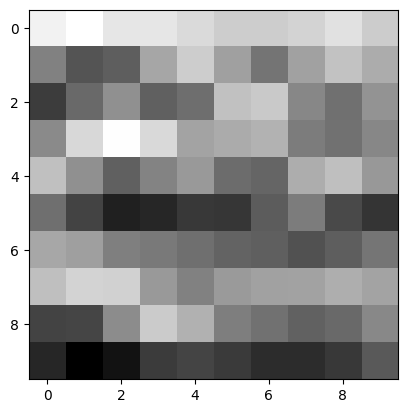

In [ ]:
padded_random_grayscale_img = np.pad(random_grayscale_img, ((1, 1), (1, 1)), 'constant')
print("Padded random grayscale image shape: ", padded_random_grayscale_img.shape)
plt.imshow(padded_random_grayscale_img, cmap='gray')
plt.show()

print("Horizontal Sobel")
plt.imshow(sobel_horizontal(padded_random_grayscale_img), cmap="gray")
plt.show()

print("Vertical Sobel")
plt.imshow(sobel_vertical(padded_random_grayscale_img), cmap="gray")
plt.show()

$\textbf{Problem}$: Generate a random $15\times 15$ grayscale image, a random $5\times 5$ kernel, and perform a $\textit{stride}$ convolution of the image with the kernel using a stride size of $2$. 

$\textbf{Solution}$: The dimension of the output image in this (unpadded) case is $(15-5)/2+1=6$.

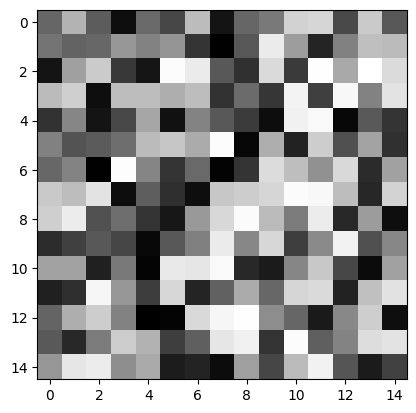

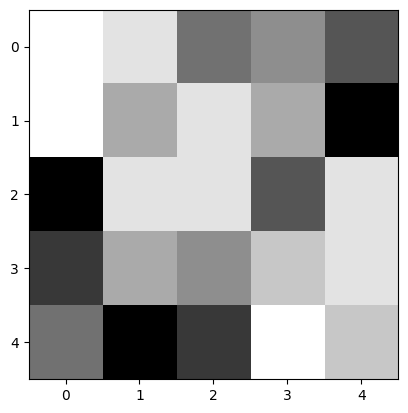

In [21]:
np.random.seed(42)
rnd_gray_img = np.random.randint(0, 256, size=(15, 15))
rnd_kernel = np.random.randint(0, 10, size=(5, 5))
plt.imshow(rnd_gray_img, cmap='gray')
plt.show()
plt.imshow(rnd_kernel, cmap='gray')
plt.show()

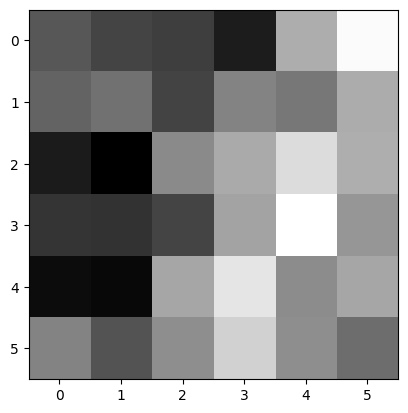

In [29]:
def stride_convolution(img, kernel, stride_size, padding):
    output_img = np.zeros(shape=(int((img.shape[0] + 2 * padding - kernel.shape[0])/stride_size + 1), int((img.shape[1] + 2 * padding - kernel.shape[1])/stride_size + 1)))
    for i in range(output_img.shape[0]):
        for j in range(output_img.shape[1]):
            output_img[i, j] = np.sum(img[i * stride_size:i * stride_size + kernel.shape[0], j * stride_size:j * stride_size + kernel.shape[1]] * kernel)
    return output_img

plt.imshow(stride_convolution(rnd_gray_img, rnd_kernel, 2, 0), cmap='gray')